In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import scipy.sparse as sp

from koala import pointsets
from koala import graph_utils as gu


from tai_localizer.perulizer import (
    proximity_bonds,
    randomly_rotate,
    sigma_y,
    proximity_lattice,
    bhz_ham,
    bhz_trs_operator,
    z2_spec_loc,
)

from tai_localizer.lauralizer.amorphous_model_BHZ_2D import amorph_BHZ
from tai_localizer.lauralizer.localizer import (
    spectral_localizer_AII2D,
    pfaff_sign,
    local_gap_localizer
)


In [70]:
# lattice parameters
rng = np.random.default_rng()

system_size = 8
bond_distance = 1.1 / system_size
beta = 1
sigma_bounds = (0.0, 0.2 / system_size)
kappa_shift = 0

# model parameters
A = 1.0
B = 1.0
delta = 2.0
delta_bounds = (-2, 4)
alpha = 0.0
onsite_disorder = 0
# disorder_bounds = (0, 15)
# hadamard_disorder = 0.15
bond_power = 1

parameters = {
        "norbs": 4,
        "rng_W": rng,
        "Delta": delta,
        "A": A,
        "B": B,
        "dis_onsite": onsite_disorder,
        "mu": 0,
        "bond_lengthscale": 1 / system_size,
        "bond_power": bond_power,
    }
# localiser parameter
kappa = 1

In [71]:
# make the points
points = pointsets.grid(system_size, system_size)

# make the lattice
edges, c = proximity_bonds(points, bond_distance)
not_crossing = np.abs(c).sum(axis=1) == 0
edges = edges[not_crossing]
# make the system in kwant
system = amorph_BHZ(points, edges)
fsyst = system.finalized()

ham = fsyst.hamiltonian_submatrix(params=parameters, sparse=True)
positions = [site.pos for site in fsyst.sites]
# compute localizer
# loc = spectral_localizer_AII2D(
# np.array(positions),
# ham,
# E0=0,
# kappa=0.1,
# time_reversal_operator=None,
# rotated=False
# )

In [77]:
import tqdm
import  scipy
from tai_localizer.lauralizer.pfaffian import pfaffian as pf
#  compute this for Delta from -1 to 2
deltas = np.linspace(-1, 4, 40)
# signatures = []
# eig = []
locgap = []
for delta in tqdm.tqdm(deltas):
    parameters["Delta"] = delta
    ham = fsyst.hamiltonian_submatrix(params=parameters, sparse=True)
    loc = spectral_localizer_AII2D(
        np.array(positions),
        ham,
        E0=0,
        kappa=1,
        time_reversal_operator=None,
        rotated=True
    )
    # vals = np.linalg.eigvalsh(loc.todense())
    # vals = pf(loc.todense(),sign_only=True)
    # eig.append(vals)
    locgap.append(local_gap_localizer(loc))
    # sig = np.sum(vals > 0) - np.sum(vals < 0)
    # signatures.append(sig)
    # print(evals)
    # print(f"Delta: {delta:.2f}, Signature: {sig}")

  0%|          | 0/40 [00:00<?, ?it/s]c:\Users\Laura\miniconda3\envs\koala\Lib\site-packages\scipy\sparse\linalg\_eigen\arpack\arpack.py:553: ComplexWarning:

Casting complex values to real discards the imaginary part

c:\Users\Laura\miniconda3\envs\koala\Lib\site-packages\scipy\sparse\linalg\_eigen\arpack\arpack.py:568: ComplexWarning:

Casting complex values to real discards the imaginary part

100%|██████████| 40/40 [00:05<00:00,  7.44it/s]


ValueError: 'c' argument has 200 elements, which is inconsistent with 'x' and 'y' with size 1.

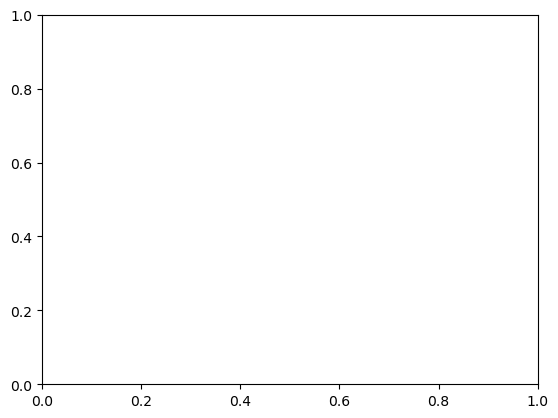

In [75]:
# plot eigenvalues vs delta
import matplotlib.pyplot as plt
#evals  of loc
eig = np.array(eig)  # aseguramos array
# array with 200 colors for the eigenvalues
colors = [f'C{i}' for i in range(200)]


for i,delta in enumerate(deltas):
    plt.scatter(delta*np.ones_like(eig[i]), eig[i], color=colors, s=10)

plt.xlabel("Delta")
plt.ylabel("Eigenvalues of Localizer")
plt.ylim(-0.25, 0.25)

(-0.1, 0.5)

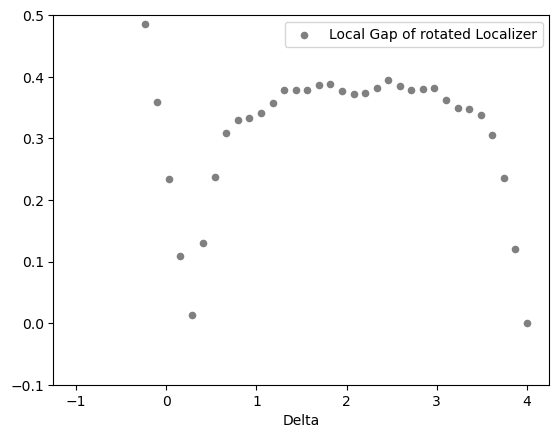

In [79]:
# plot eigenvalues vs delta
import matplotlib.pyplot as plt
#evals  of loc
for i,delta in enumerate(deltas):
    # plt.scatter(delta*np.ones_like(eig[i]), eig[i], color='blue', s=20, label='Pfaffian Rotated Localizer'  if i==0 else "")
    # plt.scatter(delta*np.ones_like(signatures[i]), signatures[i], color='red', s=20, label='Signature of Localizer' if i==0 else "")
    plt.scatter(delta*np.ones_like(locgap[i]), locgap[i], color='gray', s=20, label='Local Gap of rotated Localizer' if i==0 else "")

plt.legend()
plt.xlabel("Delta")
# plt.ylabel("signature of rotated localizer")
plt.ylim(-0.1,0.5)

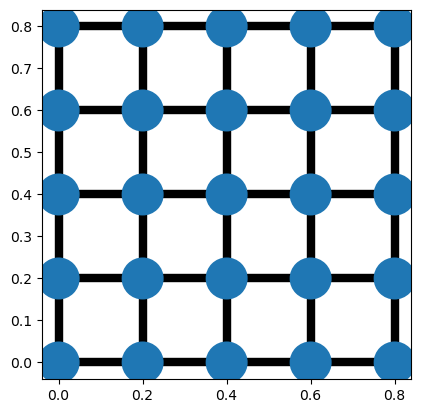

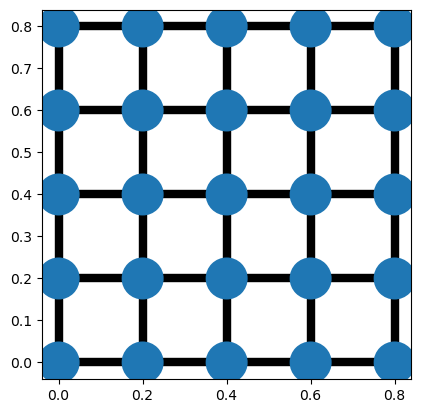

In [12]:
import kwant
kwant.plot(fsyst)

In [ ]:
# plot local density of states for delta=2 of ham
import matplotlib.pyplot as plt
from koala import plot_utils as pu
delta_index = np.argmin(np.abs(deltas - 2.0))
parameters["Delta"] = 2
ham = fsyst.hamiltonian_submatrix(params=parameters, sparse=True)
evals,  evecs = np.linalg.eigh(ham.todense())


matrix([[-2.06694095+0.j,  0.        +0.j,  0.        +0.j, ...,
          0.        +0.j,  0.        +0.j,  0.        +0.j],
        [ 0.        +0.j, -2.06694095+0.j,  0.        +0.j, ...,
          0.        +0.j,  0.        +0.j,  0.        +0.j],
        [ 0.        +0.j,  0.        +0.j,  1.93305905+0.j, ...,
          0.        +0.j,  0.        +0.j,  0.        +0.j],
        ...,
        [ 0.        +0.j,  0.        +0.j,  0.        +0.j, ...,
         -1.8686893 +0.j,  0.        +0.j,  0.        +0.j],
        [ 0.        +0.j,  0.        +0.j,  0.        +0.j, ...,
          0.        +0.j,  2.1313107 +0.j,  0.        +0.j],
        [ 0.        +0.j,  0.        +0.j,  0.        +0.j, ...,
          0.        +0.j,  0.        +0.j,  2.1313107 +0.j]],
       shape=(36, 36))